In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from io import StringIO

data = """CustomerID,Gender,Age,TenureMonths,SubscriptionType,MonthlyCharges,TotalCharges,ContractType,SupportTickets,PaymentMethod,Churn
CUST-1001,Female,34,12,Basic,49.99,599.88,Month-to-Month,3,Credit Card,Yes
CUST-1002,Male,45,24,Pro,79.99,1919.76,One Year,1,Bank Transfer,No
CUST-1003,Female,29,6,Basic,49.99,299.94,Month-to-Month,5,UPI,Yes
CUST-1004,Male,52,36,Enterprise,149.99,5399.64,Two Year,0,Credit Card,No
CUST-1005,Female,41,8,Pro,79.99,639.92,Month-to-Month,4,Debit Card,Yes
CUST-1006,Male,31,18,Basic,49.99,899.82,One Year,2,UPI,No
CUST-1007,Female,23,3,Basic,49.99,149.97,Month-to-Month,6,Credit Card,Yes
CUST-1008,Male,60,48,Enterprise,149.99,7199.52,Two Year,1,Bank Transfer,No
CUST-1009,Female,38,15,Pro,79.99,1199.85,One Year,2,Credit Card,No
CUST-1010,Male,27,4,Basic,49.99,199.96,Month-to-Month,4,UPI,Yes
CUST-1011,Female,49,30,Enterprise,149.99,4499.70,Two Year,0,Credit Card,No
CUST-1012,Male,33,14,Pro,79.99,1119.86,Month-to-Month,3,Debit Card,Yes
CUST-1013,Female,55,22,Basic,49.99,1099.78,One Year,1,Bank Transfer,No
CUST-1014,Male,26,2,Basic,49.99,99.98,Month-to-Month,5,UPI,Yes
CUST-1015,Female,43,40,Enterprise,149.99,5999.60,Two Year,1,Credit Card,No"""

df = pd.read_csv(StringIO(data))

df["ChurnFlag"] = df["Churn"].map({"Yes": 1, "No": 0})

print(df)

   CustomerID  Gender  Age  TenureMonths SubscriptionType  MonthlyCharges  \
0   CUST-1001  Female   34            12            Basic           49.99   
1   CUST-1002    Male   45            24              Pro           79.99   
2   CUST-1003  Female   29             6            Basic           49.99   
3   CUST-1004    Male   52            36       Enterprise          149.99   
4   CUST-1005  Female   41             8              Pro           79.99   
5   CUST-1006    Male   31            18            Basic           49.99   
6   CUST-1007  Female   23             3            Basic           49.99   
7   CUST-1008    Male   60            48       Enterprise          149.99   
8   CUST-1009  Female   38            15              Pro           79.99   
9   CUST-1010    Male   27             4            Basic           49.99   
10  CUST-1011  Female   49            30       Enterprise          149.99   
11  CUST-1012    Male   33            14              Pro           79.99   

In [2]:
# Basic metrics

total_customers = len(df)
churned = df["ChurnFlag"].sum()
active = total_customers - churned

churn_rate = churned / total_customers * 100

total_mrr = df["MonthlyCharges"].sum()
mrr_loss = df.loc[df["Churn"] == "Yes", "MonthlyCharges"].sum()

avg_monthly = df["MonthlyCharges"].mean()

clv = avg_monthly / (churn_rate / 100)

print("===== CUSTOMER CHURN ANALYSIS =====")
print("Total Customers:", total_customers)
print("Churned Customers:", churned)
print("Active Customers:", active)
print("Churn Rate:", round(churn_rate, 2), "%")
print("Total MRR: $", round(total_mrr, 2))
print("MRR Loss: $", round(mrr_loss, 2))
print("Average Monthly Charge: $", round(avg_monthly, 2))
print("Estimated CLV: $", round(clv, 2))

===== CUSTOMER CHURN ANALYSIS =====
Total Customers: 15
Churned Customers: 7
Active Customers: 8
Churn Rate: 46.67 %
Total MRR: $ 1269.85
MRR Loss: $ 409.93
Average Monthly Charge: $ 84.66
Estimated CLV: $ 181.41


ContractType
Month-to-Month    100.0
One Year            0.0
Two Year            0.0
Name: ChurnFlag, dtype: float64


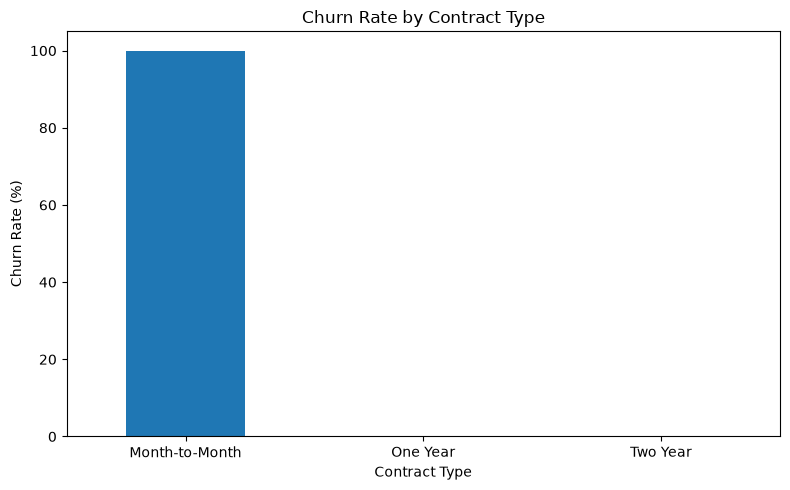

In [3]:
contract = df.groupby("ContractType")["ChurnFlag"].mean() * 100

print(contract)

plt.figure(figsize=(8,5))
contract.plot(kind="bar")
plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

PaymentMethod
Bank Transfer      0.000000
Credit Card       33.333333
Debit Card       100.000000
UPI               75.000000
Name: ChurnFlag, dtype: float64


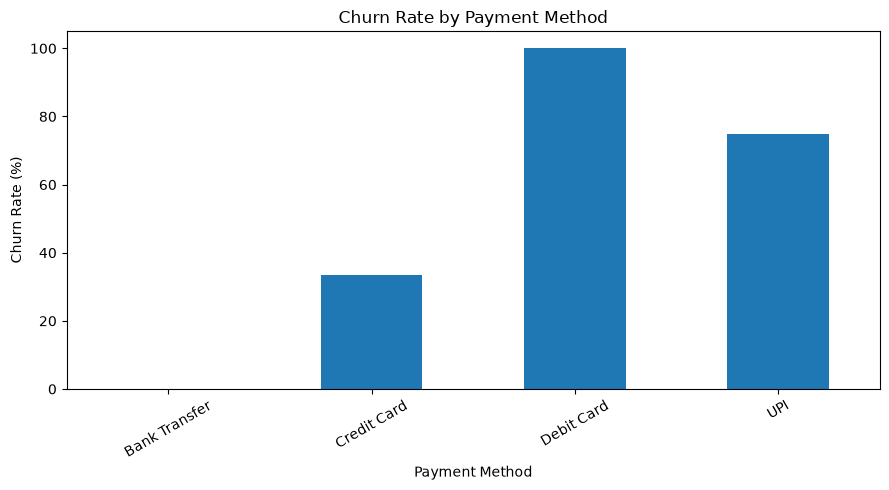

In [4]:
payment = df.groupby("PaymentMethod")["ChurnFlag"].mean() * 100

print(payment)

plt.figure(figsize=(9, 5))
payment.plot(kind="bar")
plt.title("Churn Rate by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

TenureGroup
0-12 Months     100.0
13-24 Months     20.0
25-48 Months      0.0
Name: ChurnFlag, dtype: float64


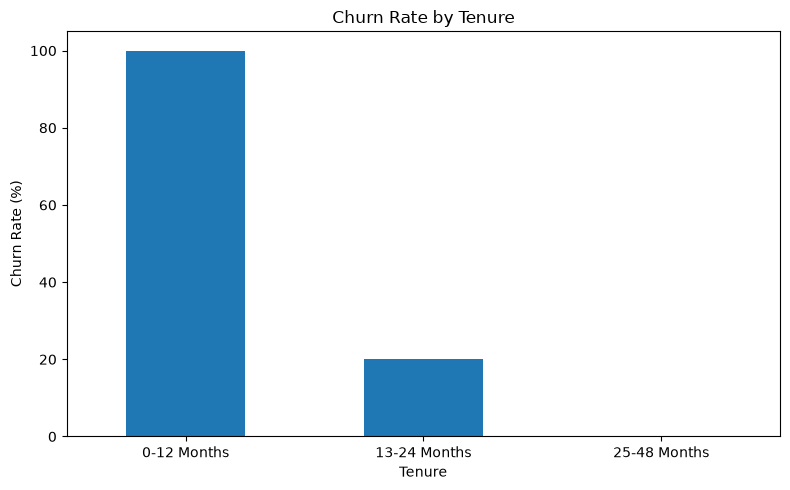

In [5]:
def tenure_group(x):
    if x <= 12:
        return "0-12 Months"
    elif x <= 24:
        return "13-24 Months"
    elif x <= 48:
        return "25-48 Months"
    else:
        return "49+ Months"

df["TenureGroup"] = df["TenureMonths"].apply(tenure_group)

tenure = df.groupby("TenureGroup")["ChurnFlag"].mean() * 100

print(tenure)

plt.figure(figsize=(8,5))
tenure.plot(kind="bar")
plt.title("Churn Rate by Tenure")
plt.xlabel("Tenure")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Churn
No     29.125
Yes     7.000
Name: TenureMonths, dtype: float64


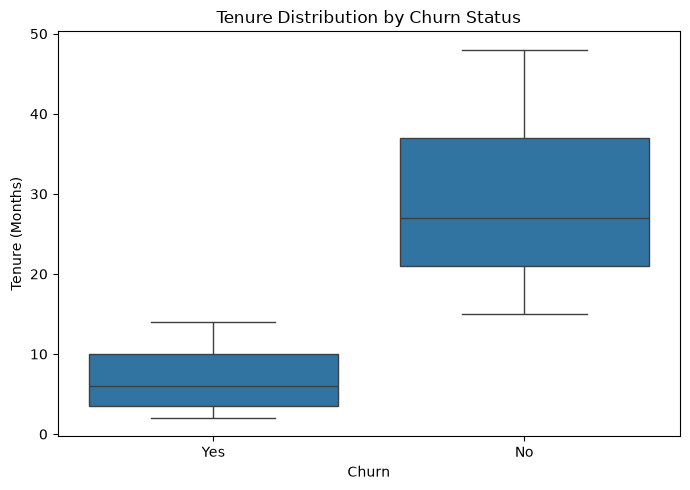

In [6]:
print(df.groupby("Churn")["TenureMonths"].mean())

plt.figure(figsize=(7,5))

sns.boxplot(
    data=df,
    x="Churn",
    y="TenureMonths"
)

plt.title("Tenure Distribution by Churn Status")
plt.xlabel("Churn")
plt.ylabel("Tenure (Months)")

plt.tight_layout()
plt.show()

Churn
No     1.000000
Yes    4.285714
Name: SupportTickets, dtype: float64


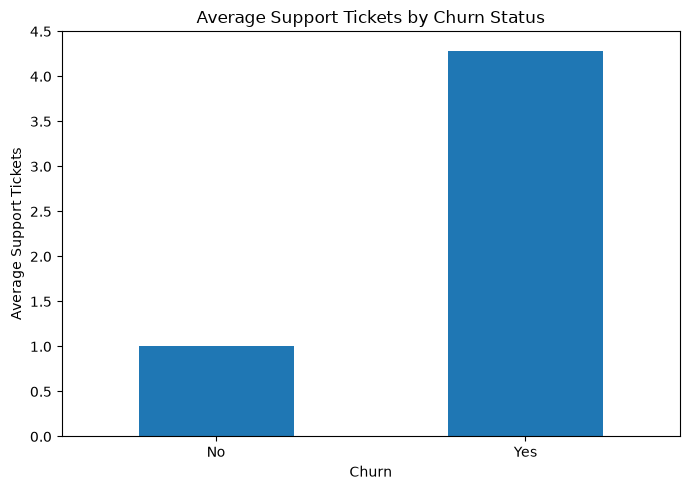

In [7]:
support = df.groupby("Churn")["SupportTickets"].mean()

print(support)

plt.figure(figsize=(7,5))
support.plot(kind="bar")
plt.title("Average Support Tickets by Churn Status")
plt.xlabel("Churn")
plt.ylabel("Average Support Tickets")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

                     Age  TenureMonths  MonthlyCharges  TotalCharges  \
Age             1.000000      0.850446        0.703486      0.759139   
TenureMonths    0.850446      1.000000        0.869103      0.955711   
MonthlyCharges  0.703486      0.869103        1.000000      0.951240   
TotalCharges    0.759139      0.955711        0.951240      1.000000   
SupportTickets -0.839999     -0.856506       -0.710592     -0.733568   
ChurnFlag      -0.734173     -0.797089       -0.591177     -0.661325   

                SupportTickets  ChurnFlag  
Age                  -0.839999  -0.734173  
TenureMonths         -0.856506  -0.797089  
MonthlyCharges       -0.710592  -0.591177  
TotalCharges         -0.733568  -0.661325  
SupportTickets        1.000000   0.882659  
ChurnFlag             0.882659   1.000000  


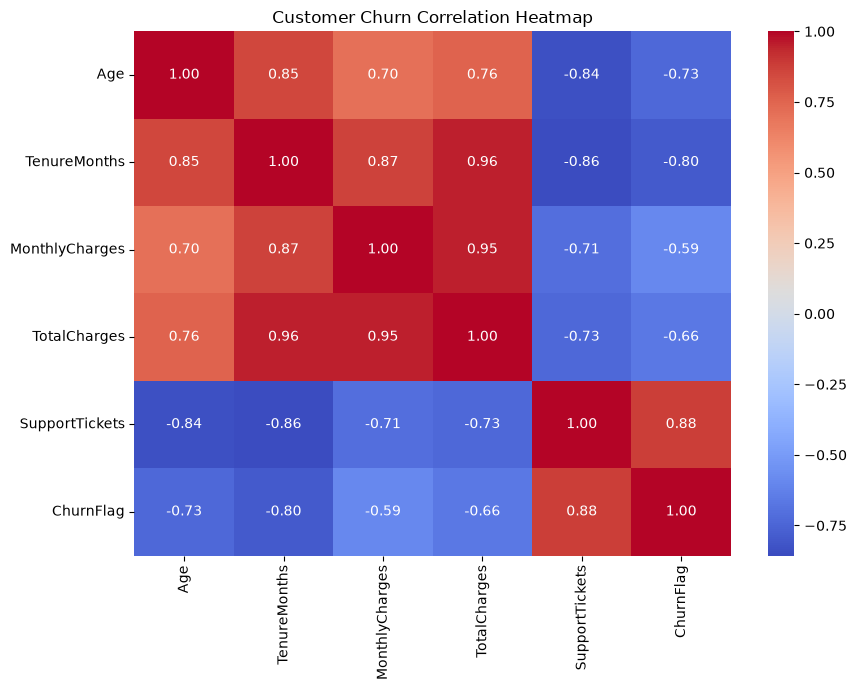

In [8]:
columns = [
    "Age",
    "TenureMonths",
    "MonthlyCharges",
    "TotalCharges",
    "SupportTickets",
    "ChurnFlag"
]

correlation = df[columns].corr()

print(correlation)

plt.figure(figsize=(9,7))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Customer Churn Correlation Heatmap")
plt.tight_layout()
plt.show()